In [1]:
import os 
from matplotlib import pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
import sourmash
import polars as pl
import glob
import seaborn as sns
import collections
from scipy.stats import norm

In [2]:
def load_fit_isect(filename):
    basename = os.path.basename(filename)
    species, _, metag, _ = basename.split('.', 3)
    species = " ".join(species.split(' ')[1:3])
    ss = list(sourmash.load_file_as_signatures(filename))[0]

    values = np.array(list(ss.minhash.hashes.values())).reshape(-1, 1)

    try:
        best_n = 2
        clf = GaussianMixture(n_components=best_n, covariance_type="spherical")
        
        clf.fit(values)
    except:
        return metag, species, -1, -1

    # automatically sort out best.
    xx = sorted(zip(range(2), clf.weights_, clf.means_), key=lambda x: -x[1])
    xx = list(xx)
    #print(xx)

    right_idx = xx[0][0]
    right_weight = xx[0][1]
    right_mean = xx[0][2][0]

    return metag, species, float(right_mean), float(right_weight)

In [3]:
def find_best_bic(values, *, verbose=False):
    # calculate best num components based on Bayesian Information Criterion score:
    bics = dict()
    for n_components in range(1, 6):
        clf = GaussianMixture(n_components=n_components, covariance_type="spherical")
        labels = clf.fit(values).predict(values)
        bics[n_components] = round(float(clf.bic(values)), 2)

    bics = list(bics.items())
    bics.sort(key=lambda x: x[1])
    best_n = bics[0][0]
    if verbose:
        print('BICS:', best_n, bics)

    return best_n

In [4]:
GMM_Peak = collections.namedtuple('GMM_Peak', ['idx', 'mean', 'weight', 'covariance'])

def gmm_fit(values, *, num_components=None, verbose=False):
    if num_components is None:
        num_components = find_best_bic(values, verbose=verbose)
    
    clf = GaussianMixture(n_components=num_components, covariance_type="spherical")
    clf.fit(values)

    orig_peaks = []
    for i in range(num_components):
        mean = float(clf.means_[i][0])
        weight = float(clf.weights_[i])
        cov = float(clf.covariances_[i])
        peak = GMM_Peak(i, mean, weight, cov)
        orig_peaks.append(peak)

    # choose largest mean with weight above 0.1
    peaks = [ p for p in orig_peaks if p.weight >= 0.1]
    peaks.sort(key=lambda x: -x.mean)
    best_peak = peaks[0]

    if verbose:
        for peak in orig_peaks:
            ch = ''
            if peak == best_peak:
                ch = '*'
            print(f'{ch}{peak.idx}: {peak.mean:.1f} {peak.weight:.3f} {peak.covariance:.3f}')

    return best_peak


In [35]:
def load_fit_plot_isect(species, metag, *, ymax=50, bins=50, num_components=None, verbose=True):
    ss = list(sourmash.load_file_as_signatures(f'../outputs.isect/3216_isect.d/{species} singlehash.x.{metag}.sig.zip'))[0]

    values = np.array(list(ss.minhash.hashes.values())).reshape(-1, 1)

     # track hashval abundance distribution
    counts_d = collections.defaultdict(int)
    # track abundance distribution, too
    counter = collections.Counter()

    for hashval, abund in ss.minhash.hashes.items():
        counts_d[hashval] += abund
        counter[abund] += 1

    all_counts = list(counts_d.values())
    counts_dist = list(counter.items())
    sum_hist = sum(counter.values())
    max_range = max(counter.values())
    min_range = 0

    # find count that covers 95% of distribution.
    sofar = 0
    for k, v in sorted(counts_dist):
        sofar += v
        if sofar >= 0.99*sum_hist:
            max_range = 2*k
            break

    fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
    sns.histplot(all_counts, ax=ax1,
                 binrange=(min_range, max_range),
                 bins=bins, kde=False, stat='density')

    ### back to GMMs

   # do fit?
    if np.mean(values) >= 2 and len(values) > 100:
        best_peak = gmm_fit(values, num_components=num_components, verbose=verbose)
        ax1.axvline(best_peak.mean, linestyle='-.', color='red')
    
        x_axis = np.arange(min_range, max_range, 0.1)
        y_axis0 = norm.pdf(x_axis, best_peak.mean, np.sqrt(best_peak.covariance)) * best_peak.weight
        ax1.plot(x_axis, y_axis0, color='red')
    else:
        ax1.axvline(np.mean(values), linestyle='-.', color='red')

    fig.suptitle(f'{species}.x.{metag}')

    plt.show()

## Try out some good ones 

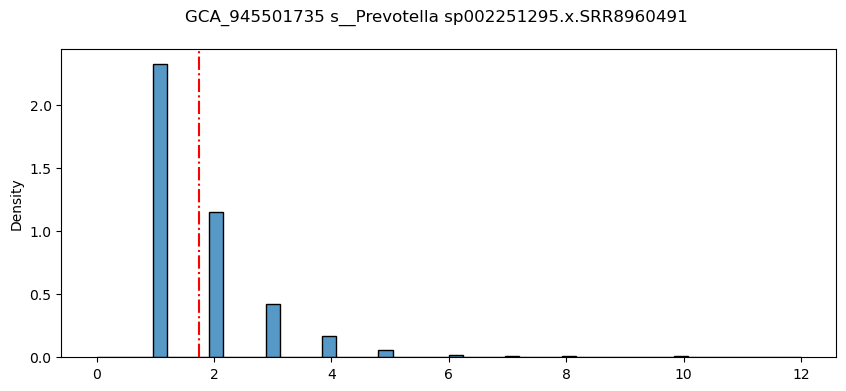

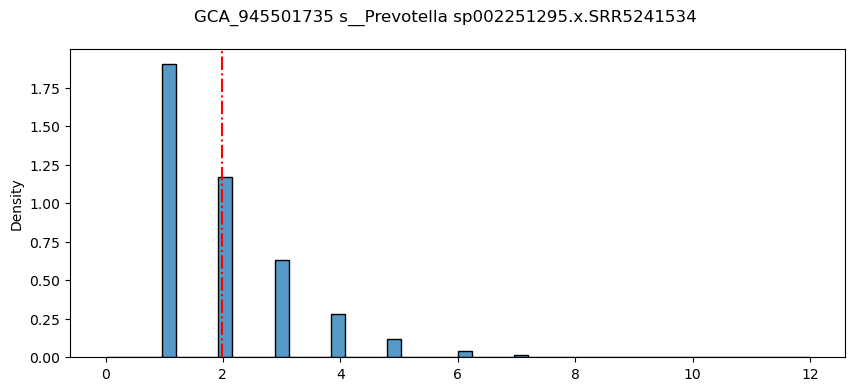

BICS: 5 [(5, 4096.32), (4, 4141.7), (3, 4161.77), (2, 4252.94), (1, 4818.97)]
0: 3.7 0.461 0.970
1: 9.5 0.024 1.709
*2: 6.3 0.207 1.107
3: 1.5 0.292 0.283
4: 19.6 0.015 49.451


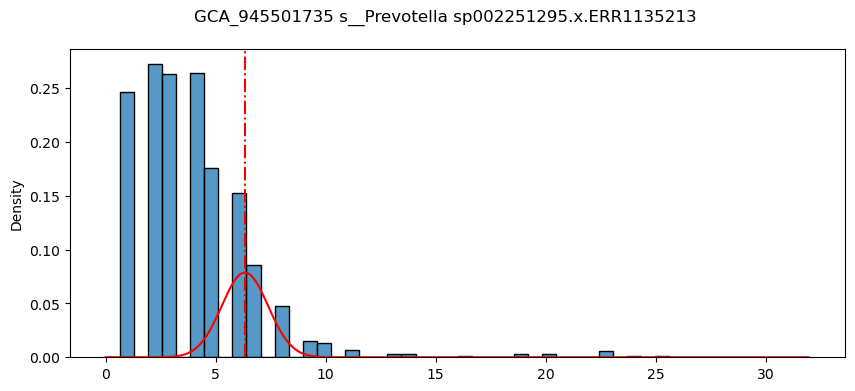

BICS: 4 [(4, 9593.05), (5, 9602.93), (3, 9772.97), (2, 9786.9), (1, 10859.26)]
0: 3.6 0.193 2.069
*1: 14.6 0.229 29.727
2: 10.8 0.322 9.798
3: 1.3 0.256 0.198


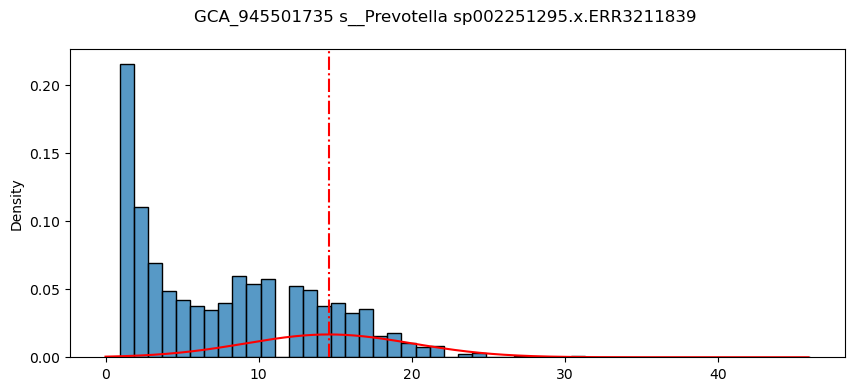

BICS: 5 [(5, 4723.52), (4, 9614.34), (3, 9657.34), (2, 9658.93), (1, 10929.43)]
*0: 18.3 0.199 14.321
1: 1.0 0.215 0.000
2: 11.2 0.380 16.719
3: 2.9 0.202 0.859
4: 36.4 0.004 213.003


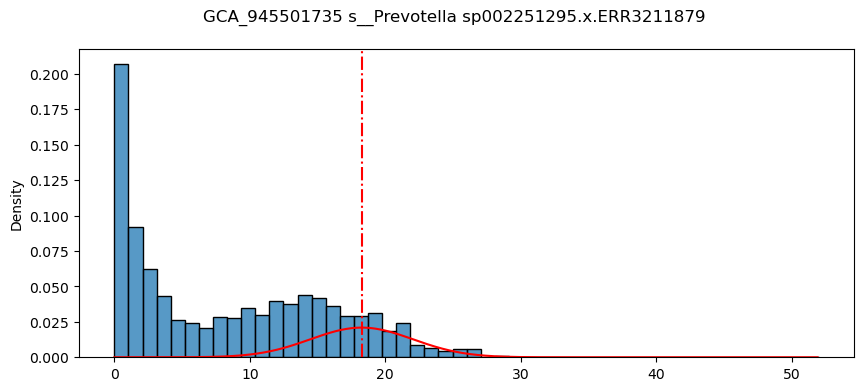

BICS: 4 [(4, 9814.16), (5, 9836.34), (3, 10077.97), (2, 10119.52), (1, 11495.25)]
0: 7.6 0.282 14.637
*1: 16.8 0.360 18.406
2: 1.6 0.350 0.555
3: 32.4 0.007 263.574


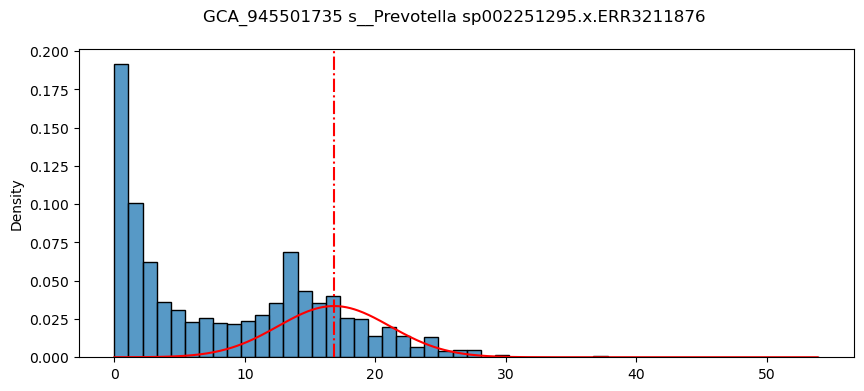

BICS: 3 [(3, 9445.45), (4, 9468.0), (5, 9479.13), (2, 9593.28), (1, 10399.14)]
0: 32.2 0.040 404.601
1: 2.2 0.289 1.446
*2: 20.0 0.671 59.744


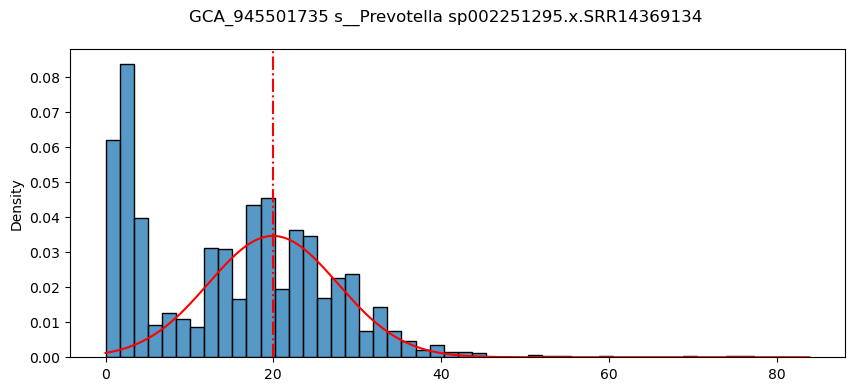

BICS: 5 [(5, 12493.21), (4, 12504.2), (3, 12819.37), (2, 12862.76), (1, 14829.51)]
0: 1.6 0.307 0.628
1: 25.5 0.315 47.802
2: 5.8 0.230 7.588
*3: 30.6 0.147 65.055
4: 106.0 0.000 0.000


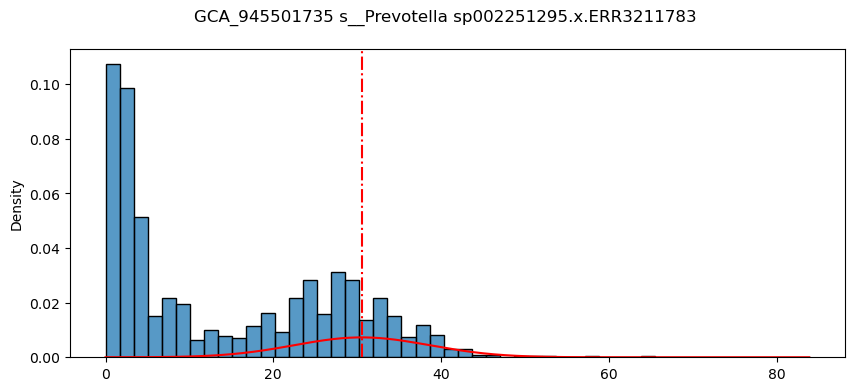

BICS: 4 [(4, 11234.24), (5, 11236.8), (3, 11269.09), (2, 11345.41), (1, 12676.1)]
0: 2.7 0.314 3.009
*1: 42.0 0.389 66.127
2: 40.0 0.088 543.564
3: 25.9 0.208 182.111


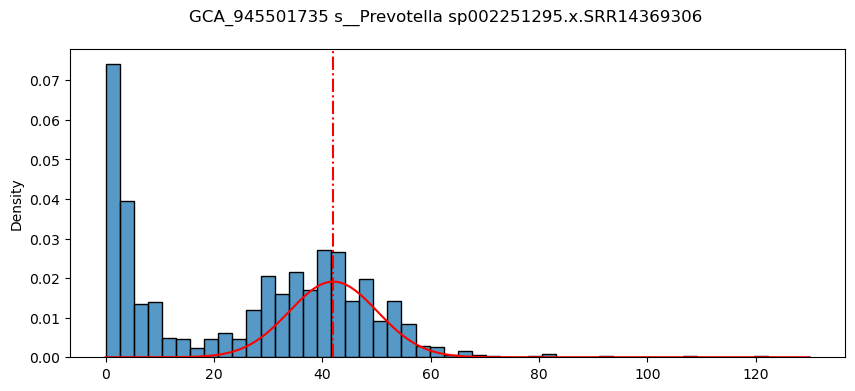

BICS: 3 [(3, 12297.67), (5, 12303.99), (4, 12340.89), (2, 12444.54), (1, 13909.99)]
0: 3.8 0.380 9.808
*1: 45.6 0.439 72.958
2: 42.1 0.181 522.152


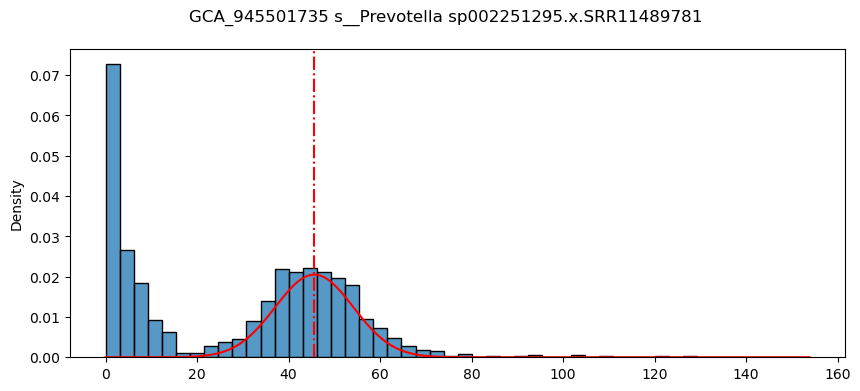

In [36]:
SS='GCA_945501735 s__Prevotella sp002251295'

METAGS=[
 'SRR8960491',
 'SRR5241534',
 'ERR1135213',
 'ERR3211839',
 'ERR3211879',
 'ERR3211876',
 'SRR14369134',
 'ERR3211783',
 'SRR14369306',
 'SRR11489781']

#plot_covhist_panel(SS, METAGS, ymax=100)

for i in METAGS:
    load_fit_plot_isect(SS, i)

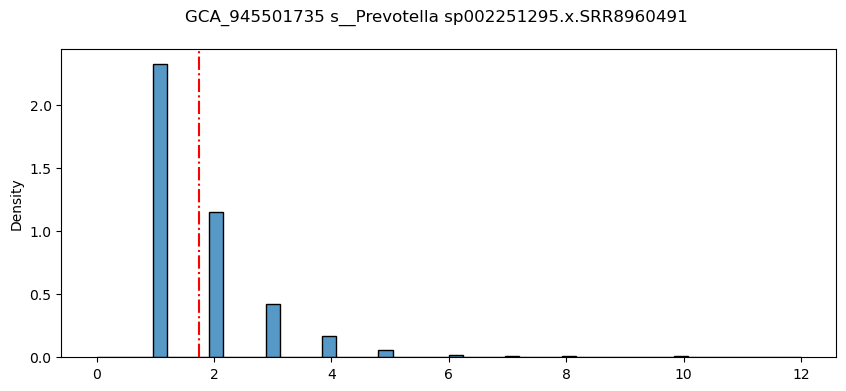

In [37]:
SS='GCA_945501735 s__Prevotella sp002251295'
load_fit_plot_isect(SS, 'SRR8960491')

## Misc prevotella IGNORE

In [38]:
SS='GCA_945501735 s__Prevotella sp002251295'

METAGS=[
 'SRR8960491',
 'SRR5241534',
 'ERR1135213',
 'ERR3211839',
 'ERR3211879',
 'ERR3211876',
 'SRR14369134',
 'ERR3211783',
 'SRR14369306',
 'SRR11489781']

#plot_covhist_panel(SS, METAGS, ymax=100)

for i in METAGS:
    filename = f'../outputs.isect/3216_isect.d/{SS} singlehash.x.{i}.sig.zip'
    print(load_fit_isect(filename))

('SRR8960491', 's__Prevotella sp002251295', 1.3103867245022343, 0.7716318654055586)
('SRR5241534', 's__Prevotella sp002251295', 1.3327933488832562, 0.6375097756730058)
('ERR1135213', 's__Prevotella sp002251295', 3.615470464953081, 0.9557608708265979)
('ERR3211839', 's__Prevotella sp002251295', 10.806530250491825, 0.680833928687434)
('ERR3211879', 's__Prevotella sp002251295', 12.793304136643183, 0.644903191934401)
('ERR3211876', 's__Prevotella sp002251295', 13.16376836997501, 0.6388821796093369)
('SRR14369134', 's__Prevotella sp002251295', 20.341896760415068, 0.7247028087260742)
('ERR3211783', 's__Prevotella sp002251295', 23.88795191443406, 0.558553575117516)
('SRR14369306', 's__Prevotella sp002251295', 37.85991539301757, 0.6638205737186494)
('SRR11489781', 's__Prevotella sp002251295', 45.22406793023974, 0.6092714647906161)


## Load lacto kmer coverage estimates

In [39]:
lacto_kmer_df = pl.read_csv('../outputs.isect/s__Lactobacillus amylovorus.isect.abund.csv')

## Plot some high abundance ones

In [40]:
lacto_kmer_df = lacto_kmer_df.sort('abund', descending=True).drop_nans()
lacto_kmer_df

metag,species,abund
str,str,f64
"""SRR11185260""","""s__Lactobacillus amylovorus""",2282.732405
"""SRR11185246""","""s__Lactobacillus amylovorus""",2207.071085
"""SRR16235702""","""s__Lactobacillus amylovorus""",2045.930849
"""SRR18048904""","""s__Lactobacillus amylovorus""",1942.0
"""SRR16235689""","""s__Lactobacillus amylovorus""",1924.562551
…,…,…
"""ERR3211822""","""s__Lactobacillus amylovorus""",1.0
"""ERR3211990""","""s__Lactobacillus amylovorus""",1.0
"""SRR7182060""","""s__Lactobacillus amylovorus""",1.0


BICS: 4 [(4, 6123.35), (5, 6130.35), (3, 6137.28), (2, 6713.09), (1, 9912.07)]
0: 1.9 0.488 1.492
1: 1365.5 0.159 485087.759
2: 49.6 0.239 1817.284
*3: 2282.7 0.115 93195.060


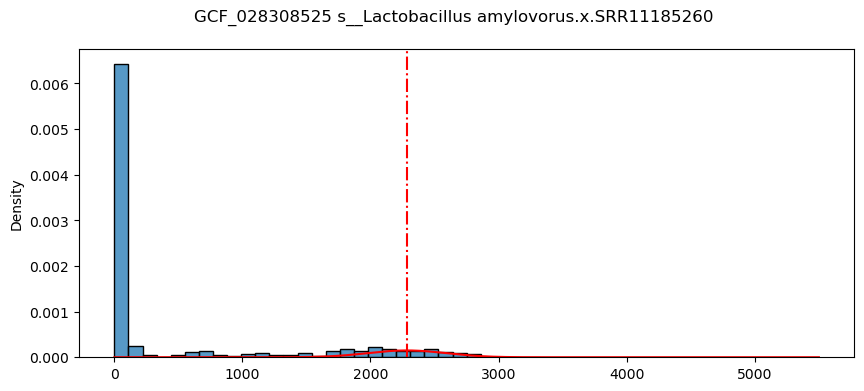

BICS: 3 [(3, 6882.23), (4, 6901.81), (2, 7324.65), (5, 9075.48), (1, 11991.7)]
0: 3.3 0.656 10.021
1: 81.0 0.176 10673.355
*2: 2224.5 0.168 178916.068


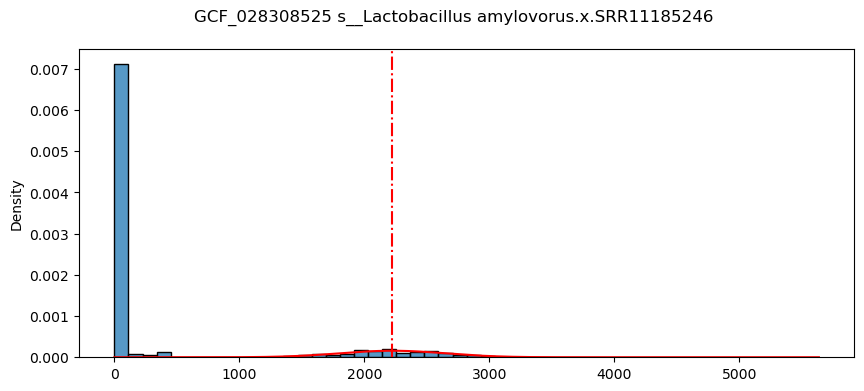

BICS: 2 [(2, 5000.94), (3, 5021.16), (4, 5030.1), (5, 5049.52), (1, 7723.4)]
*0: 2045.9 0.276 131998.999
1: 8.4 0.724 158.020


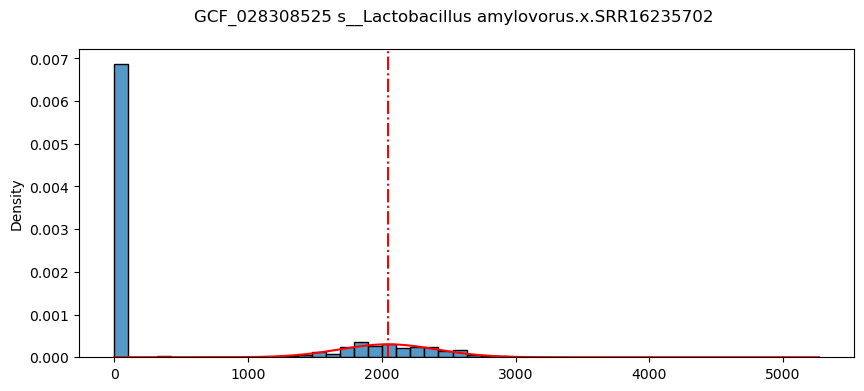

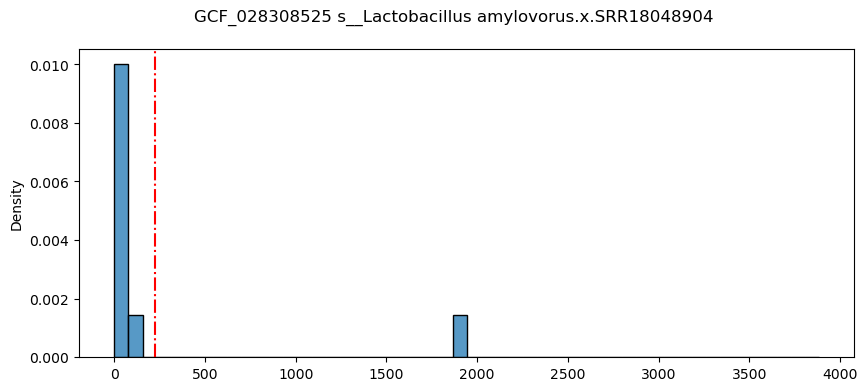

BICS: 3 [(3, 4582.32), (4, 4599.68), (5, 4610.2), (2, 4846.39), (1, 7460.83)]
0: 1.8 0.518 1.349
*1: 1924.6 0.290 90616.663
2: 146.2 0.192 34888.424


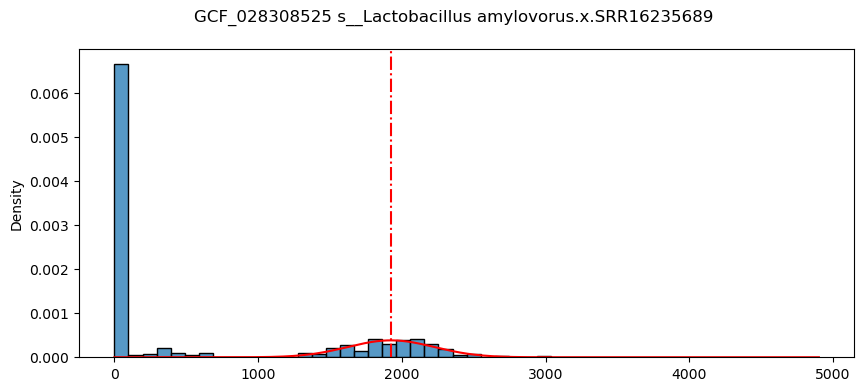

BICS: 3 [(3, 5172.56), (5, 5415.47), (4, 5420.51), (2, 5606.55), (1, 8317.38)]
0: 1.7 0.490 1.158
*1: 1854.1 0.299 359311.720
2: 55.0 0.211 4041.309


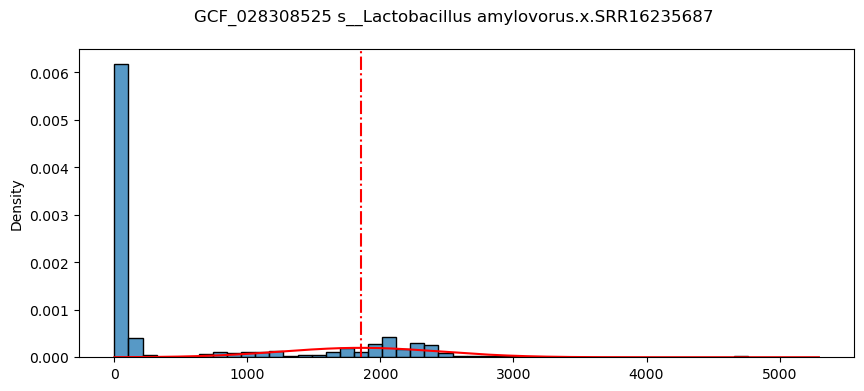

BICS: 5 [(5, 3878.48), (3, 3915.08), (4, 3930.83), (2, 3968.04), (1, 6457.2)]
0: 1.6 0.529 0.950
1: 1307.9 0.207 19839.916
2: 690.7 0.130 420456.264
3: 2616.0 0.008 18814.900
*4: 1701.5 0.126 21293.000


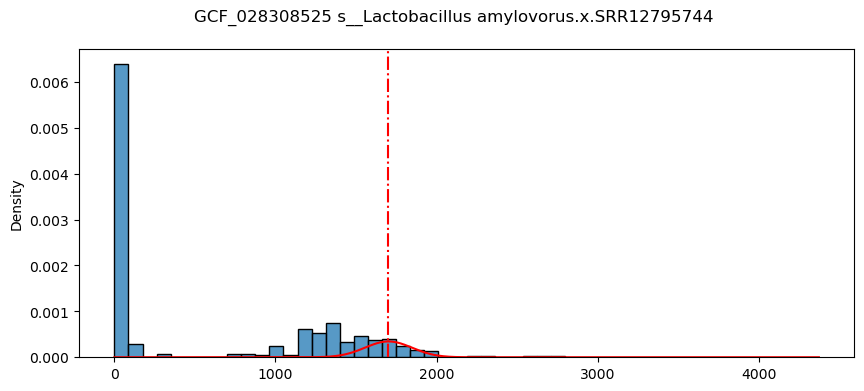

BICS: 4 [(4, 5626.35), (2, 5998.21), (3, 7616.29), (5, 7658.51), (1, 10472.25)]
0: 2.5 0.657 3.528
*1: 1434.3 0.154 63208.050
2: 2017.0 0.052 8857.593
3: 58.4 0.137 3028.692


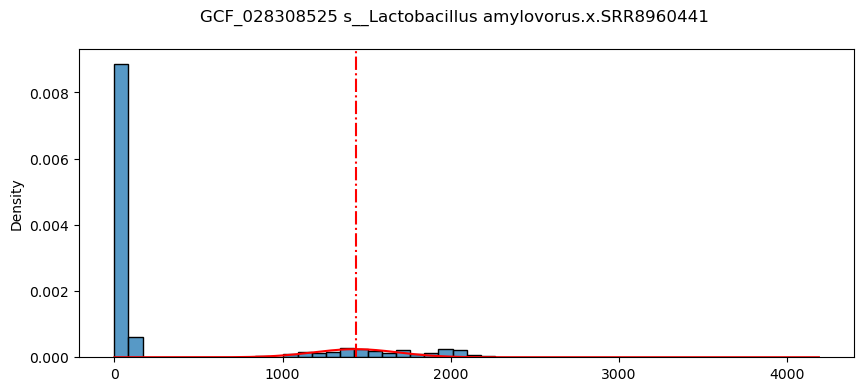

BICS: 5 [(5, 5925.45), (4, 6006.51), (3, 6026.9), (2, 6847.34), (1, 10999.33)]
0: 1.4 0.429 0.370
1: 2395.8 0.021 8365.262
2: 12.5 0.311 99.993
*3: 2461.6 0.161 666743.555
4: 181.9 0.078 19202.330


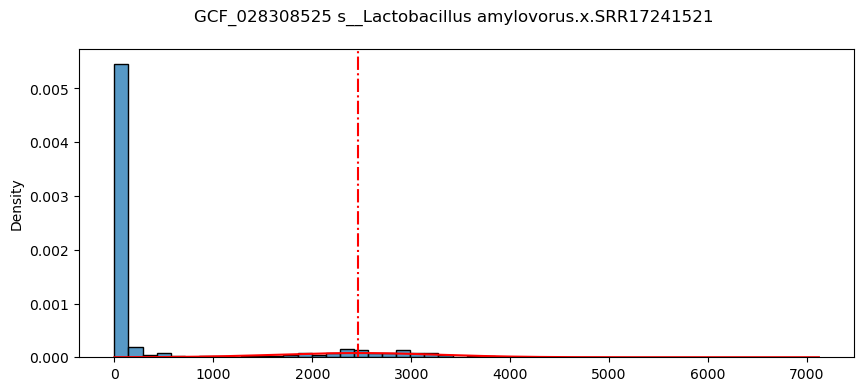

BICS: 3 [(3, 5850.33), (4, 5873.18), (5, 5892.6), (2, 6264.71), (1, 11498.79)]
0: 2.5 0.699 3.696
*1: 1333.1 0.166 93040.845
2: 33.2 0.135 1452.986


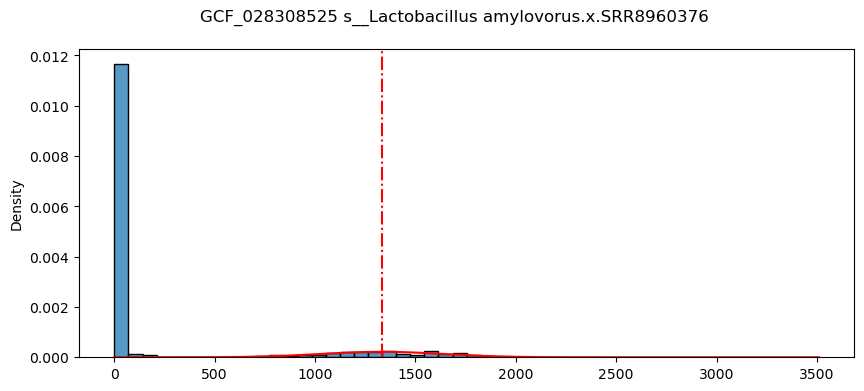

In [41]:
for metag in lacto_kmer_df.head(10)['metag']:
    load_fit_plot_isect('GCF_028308525 s__Lactobacillus amylovorus', metag)

In [32]:
lacto_kmer_df

metag,species,abund
str,str,f64
"""SRR11185260""","""s__Lactobacillus amylovorus""",2282.732405
"""SRR11185246""","""s__Lactobacillus amylovorus""",2207.071085
"""SRR16235702""","""s__Lactobacillus amylovorus""",2045.930849
"""SRR18048904""","""s__Lactobacillus amylovorus""",1942.0
"""SRR16235689""","""s__Lactobacillus amylovorus""",1924.562551
…,…,…
"""ERR3211822""","""s__Lactobacillus amylovorus""",1.0
"""ERR3211990""","""s__Lactobacillus amylovorus""",1.0
"""SRR7182060""","""s__Lactobacillus amylovorus""",1.0


In [33]:
depth_df = pl.read_csv('../mapping-depth.csv')

In [34]:
lacto_depth_df = depth_df.filter(pl.col('gene') == 'AtH2023_SRR8960431_MAG03_43_3')

In [15]:
lacto_depth_df

metag,gene,len,hits,breadth,depth_all,depth_cov,species
str,str,i64,i64,f64,f64,f64,str
"""ERR3211766""","""AtH2023_SRR8960431_MAG03_43_3""",1158,507,0.437824,0.452504,1.033531,"""s__Lactobacillus amylovorus"""
"""SRR11126273""","""AtH2023_SRR8960431_MAG03_43_3""",1158,442,0.381693,0.468912,1.228507,"""s__Lactobacillus amylovorus"""
"""SRR8960968""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,397.020725,397.020725,"""s__Lactobacillus amylovorus"""
"""SRR14369136""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,20.554404,20.554404,"""s__Lactobacillus amylovorus"""
"""SRR17241596""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,320.746978,320.746978,"""s__Lactobacillus amylovorus"""
…,…,…,…,…,…,…,…
"""ERR3211783""","""AtH2023_SRR8960431_MAG03_43_3""",1158,302,0.260794,0.260794,1.0,"""s__Lactobacillus amylovorus"""
"""SRR14812369""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,39.916235,39.916235,"""s__Lactobacillus amylovorus"""
"""SRR8655115""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,7.477547,7.477547,"""s__Lactobacillus amylovorus"""


In [16]:
lacto_all_df = lacto_depth_df.join(lacto_kmer_df, on='metag')
lacto_all_df

metag,gene,len,hits,breadth,depth_all,depth_cov,species,species_right,abund
str,str,i64,i64,f64,f64,f64,str,str,f64
"""SRR18048904""","""AtH2023_SRR8960431_MAG03_43_3""",1158,0,0.0,0.0,NaN,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",1942.0
"""SRR17241521""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,3919.845423,3919.845423,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",1340.974504
"""SRR10209683""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,866.379102,866.379102,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",526.305482
"""SRR8960379""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,454.301382,454.301382,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",295.887562
"""SRR14812372""","""AtH2023_SRR8960431_MAG03_43_3""",1158,1158,1.0,495.232297,495.232297,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",293.229762
…,…,…,…,…,…,…,…,…,…
"""SRR11124687""","""AtH2023_SRR8960431_MAG03_43_3""",1158,0,0.0,0.0,NaN,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",3.194252
"""SRR12795790""","""AtH2023_SRR8960431_MAG03_43_3""",1158,139,0.120035,0.240069,2.0,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",2.0
"""SRR8960478""","""AtH2023_SRR8960431_MAG03_43_3""",1158,843,0.727979,1.346287,1.849348,"""s__Lactobacillus amylovorus""","""s__Lactobacillus amylovorus""",1.231989


Text(0.5, 1.0, 's__Lactobacillus amylovorus')

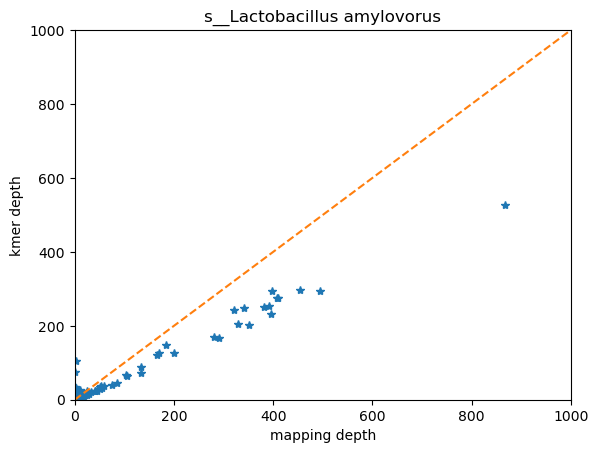

In [17]:
MAX=1000
plt.plot(lacto_all_df['depth_all'], lacto_all_df['abund'], '*')
plt.plot([0, MAX], [0, MAX], '--')
plt.xlim(0, MAX)
plt.ylim(0, MAX)
plt.xlabel('mapping depth')
plt.ylabel('kmer depth')
plt.title('s__Lactobacillus amylovorus')

## Try out prevotella

In [42]:
depth_df

metag,gene,len,hits,breadth,depth_all,depth_cov,species
str,str,i64,i64,f64,f64,f64,str
"""ERR3211766""","""AtH2023_ERR1135319_MAG02_1_7""",1572,919,0.584606,1.110051,1.898803,"""s__Bariatricus sp004560705"""
"""ERR3211766""","""AtH2023_ERR1135319_MAG02_1_10""",2022,1031,0.509891,0.654303,1.28322,"""s__Bariatricus sp004560705"""
"""ERR3211766""","""AtH2023_ERR1135319_MAG02_1_13""",861,0,0.0,0.0,NaN,"""s__Bariatricus sp004560705"""
"""ERR3211766""","""AtH2023_ERR1135319_MAG02_1_23""",1878,878,0.467519,0.643237,1.375854,"""s__Bariatricus sp004560705"""
"""ERR3211766""","""AtH2023_ERR1135319_MAG02_1_27""",2493,1415,0.567589,1.186923,2.091166,"""s__Bariatricus sp004560705"""
…,…,…,…,…,…,…,…
"""SRR11125751""","""AtH2023_SRR8960831_MAG08_7_11""",126,0,0.0,0.0,NaN,"""s__UBA2868 sp004552595"""
"""SRR11125751""","""AtH2023_ERR1135443_MAG08_149_1""",504,0,0.0,0.0,NaN,"""s__UBA2868 sp004552595"""
"""SRR11125751""","""AtH2023_SRR14369154_MAG04_52_1…",2283,29,0.012703,0.012703,1.0,"""s__UBA2868 sp004552595"""


In [18]:
prevotella_kmer_df = pl.read_csv('../outputs.isect/s__Prevotella sp002251295.isect.abund.csv')

In [19]:
prevotella_depth_df = depth_df.filter(pl.col('gene') == 'AtH2023_ERR3211937_MAG3_16_9')

In [20]:
prevotella_all_df = prevotella_depth_df.join(prevotella_kmer_df, on='metag')

Text(0.5, 1.0, 's__Prevotella sp002251295')

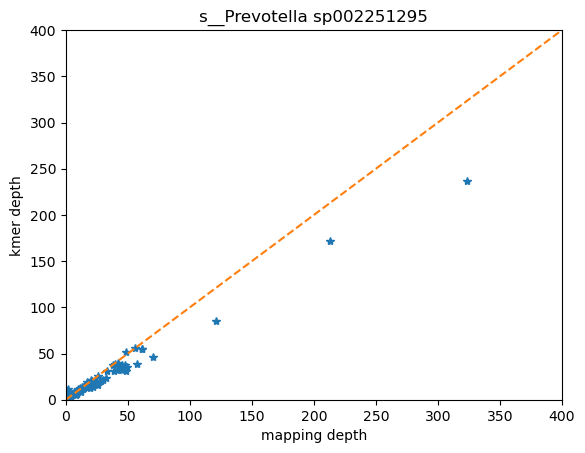

In [21]:
MAX=400
plt.plot(prevotella_all_df['depth_all'], prevotella_all_df['abund'], '*')
plt.plot([0, MAX], [0, MAX], '--')
plt.xlim(0, MAX)
plt.ylim(0, MAX)
plt.xlabel('mapping depth')
plt.ylabel('kmer depth')
plt.title('s__Prevotella sp002251295')

## Plot all of the ones for which we have anchor genes?

In [43]:
new_genes_df = pl.read_csv('../new_genes_df.csv')

In [49]:
combo_genes_df = depth_df.join(new_genes_df.filter(pl.col('anchor') == 1), left_on='gene', right_on='gene_name', how='inner', coalesce=True)

In [50]:
combo_kmer_df = pl.read_csv('../outputs.isect/*.csv')

In [56]:
all_df = combo_genes_df.join(combo_kmer_df, on=['metag', 'species'], how='inner')

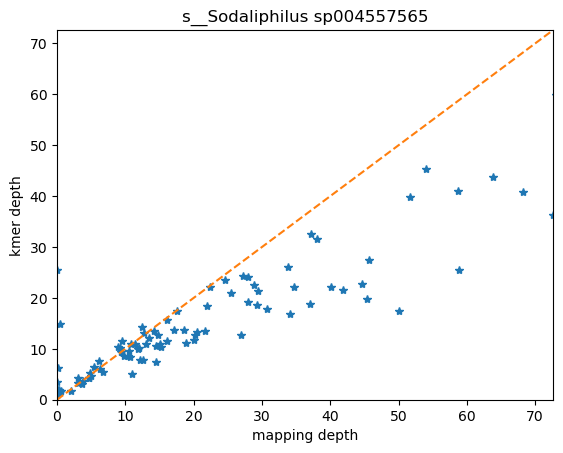

SKIPPING: s__Cryptobacteroides sp900546925
SKIPPING: s__Mogibacterium_A kristiansenii
SKIPPING: s__Cryptobacteroides sp034089285
SKIPPING: s__Colivicinus sp002299675
SKIPPING: s__Cryptobacteroides sp000434935
SKIPPING: s__Ornithospirochaeta sp022785155
SKIPPING: s__Floccifex porci


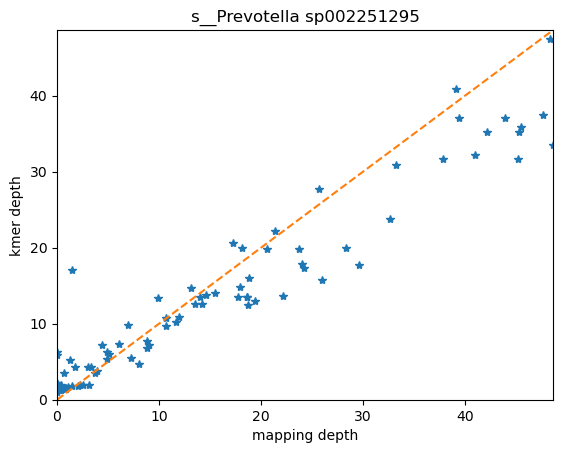

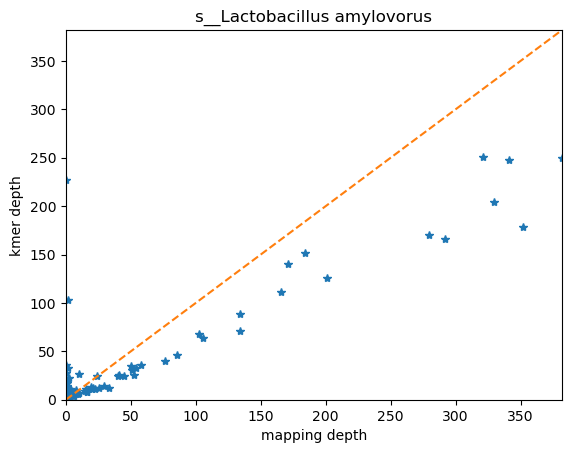

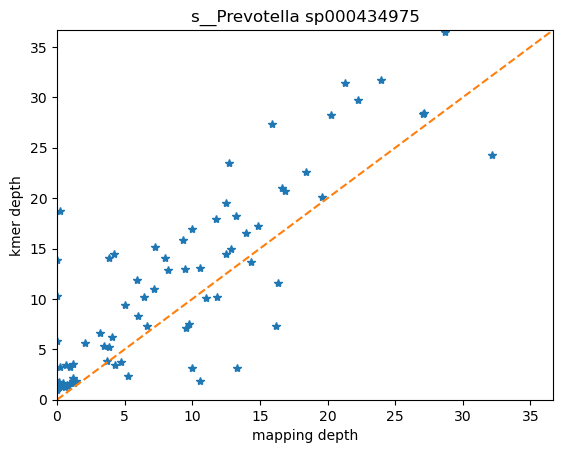

SKIPPING: s__Fimisoma sp002320005
SKIPPING: s__UBA2868 sp004552595


In [60]:
for species in all_df['species'].unique():
    xx_df = all_df.filter(pl.col('species') == species)

    depths = list(sorted(xx_df['depth_all']))
    MAX = depths[int(len(depths) * 0.9)]

    if MAX < 20:
        print('SKIPPING:', species)
        continue
    
    plt.plot(xx_df['depth_all'], xx_df['abund'], '*')
    plt.plot([0, MAX], [0, MAX], '--')
    plt.xlim(0, MAX)
    plt.ylim(0, MAX)
    plt.xlabel('mapping depth')
    plt.ylabel('kmer depth')
    plt.title(species)
    plt.show()